In [17]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [18]:
# In Jupyter, __file__ is not defined. Use the notebook's working directory.
file_path = Path().resolve()
root_dir = file_path
map_path = root_dir / "data" / "map.png"

print(f"Root directory: {root_dir}")
print(f"Map path: {map_path}")

Root directory: D:\rober\Documents\GitHub\edth-2025
Map path: D:\rober\Documents\GitHub\edth-2025\data\map.png


In [19]:
patches_path = root_dir / "map_processing" / "patches"

patches_paths = list(patches_path.glob("*.png"))

patches = []

for patch_path in patches_paths:
    patch = cv2.imread(str(patch_path), cv2.IMREAD_UNCHANGED)
    if patch is not None:
        patches.append(patch)
    else:
        print(f"Failed to read patch: {patch_path}")

In [20]:
orb = cv2.ORB_create(nfeatures=1000)

patch_descriptors = []

for i, patch_img in enumerate(patches):

    keypoints, descriptors = orb.detectAndCompute(patch_img, None)
    patch_descriptors.append({
        "keypoints": keypoints,
        "descriptors": descriptors,
        "name": patches_paths[i].name
    })


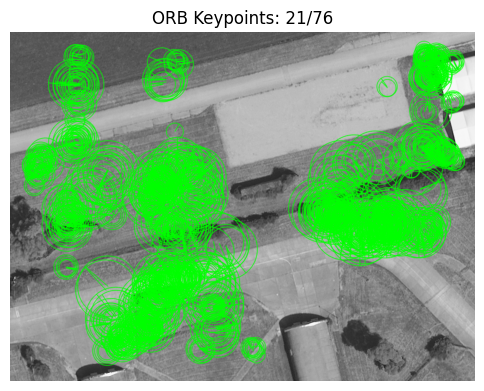

In [21]:
lb = 20
ub = lb + 1

for i, patch_data in enumerate(patch_descriptors[lb:ub]):
    patch_img = patches[i + lb]
    # Draw keypoints on the image
    img_with_kp = cv2.drawKeypoints(
        patch_img, keypoints, None,
        color=(0, 255, 0), flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )

    # Display using matplotlib
    plt.figure(figsize=(6, 6))
    plt.title(f"ORB Keypoints: {i + lb + 1}/{len(patch_descriptors)}")
    plt.imshow(img_with_kp)
    plt.axis('off')
    plt.show()

In [22]:
input_img_path = root_dir / "data" / "train_data" / "train_images" / "0013.JPG"

input_img = cv2.imread(str(input_img_path), cv2.IMREAD_GRAYSCALE)
if input_img is None:
    raise FileNotFoundError(f"Image not found at {map_path}")

# Downsample the image by a factor of 11 in each dimension
scale_factor = 11
height, width = input_img.shape[:2]
new_size = (width // scale_factor, height // scale_factor)

downsampled_img = cv2.resize(input_img, new_size, interpolation=cv2.INTER_AREA)

input_keypoints, input_descriptors = orb.detectAndCompute(patch_img, None)


In [24]:


bf = cv2.BFMatcher(cv2.NORM_HAMMING)
patch_scores = []  # Store (score, matched_img, patch metadata) tuples

for i, patch in enumerate(patch_descriptors):
    descriptors = patch["descriptors"]
    if descriptors is None or input_descriptors is None:
        continue  # Skip if no descriptors

    matches = bf.match(descriptors, input_descriptors)
    if not matches:
        continue

    # Sort matches by distance (lower is better)
    matches = sorted(matches, key=lambda x: x.distance)

    # Calculate a score: e.g., average distance of top 10 matches
    N = min(10, len(matches))
    score = sum([m.distance for m in matches[:N]]) / N

    # # Generate matched image for later use
    # matched_img = cv2.drawMatches(
    #     patches[i], patch["keypoints"],
    #     input_img, input_keypoints,
    #     matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    # )

    # Store the score and corresponding image
    patch_scores.append((score, patch))

# Sort all patches by match score (lower is better)
patch_scores = sorted(patch_scores, key=lambda x: x[0])

# Show top K best matching patches
top_K = 5
for i in range(min(top_K, len(patch_scores))):
    score, patch = patch_scores[i]

    print(f"Patch: {patch['name']}, Score: {score:.2f}")

Patch: patch_0010.png, Score: 0.00
Patch: patch_0011.png, Score: 0.00
Patch: patch_0020.png, Score: 0.00
Patch: patch_0021.png, Score: 0.00
Patch: patch_0030.png, Score: 0.00


In [ ]:
train_images_dir = root_dir / "data" / "train_data" / "train_images"

train_images = []

for img_path in train_images_dir.glob("*.JPG"):
    
    img = Image.open(img_path)
    if img is not None:
        height, width = img.size
        aspect_ratio = width / height
        
        train_images.append({
            "path": img_path,
            "height": height,
            "width": width,
            "aspect_ratio": aspect_ratio
        })
    else:
        print("Image not found or failed to load.")


In [ ]:
train_cam = root_dir / "data" / "train_data" / "train_cam.csv"

train_cam_df = pd.read_csv(train_cam)

for idx, row in train_cam_df.iterrows():
    
    train_images[idx]["focal_len"] = {
        "x": row["fx"],
        "y": row["fy"]
    }

In [ ]:
alt = 200 # m
pixel_size = 2.4 * 10**-3  # mm, typical pixel size for UAV cameras


"""
GSD = (altitude * pixel_size) / focal_length
    GSD in m / pixel
    altitude in m
    pixel_size in mm / pixel
    focal_length in mm
"""

for i, img in enumerate(train_images):
    
    img["gsd"] = {
        "x": alt * pixel_size / img["focal_len"]["x"],
        "y": alt * pixel_size / img["focal_len"]["y"]
    }

    print(f"Image {i + 1}/{len(train_images)} - gsd_x: {img['gsd']['x']} m, gsd_y: {img['gsd']['y']} m")

Image 1/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 2/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 3/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 4/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 5/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 6/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 7/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 8/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 9/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 10/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 11/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 12/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 13/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-